In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tbparse

2024-12-16 09:51:27.432632: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-16 09:51:27.432688: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-16 09:51:27.432699: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-16 09:51:27.441361: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
final_csv_path = './result_csvs_and_pdfs/FINAL.csv'
final_df = pd.read_csv(final_csv_path)
final_df

,Unnamed: 0,model,train_data,test_data,device,timestamp,n_hyperparam_trials,learning_rate,batch_size,accum_grad_batches,...,test_auroc,test_loss,train_walltime,hyperparam_json_path,hyperparam_log_path,train_log_path,test_log_path,summary_log_path,trained_model_ckpt_path,tested_model_ckpt_path
0,0,TraverseNN,FourLeafTrain,FourLeafTest,cpu,TODAY,10,0.000894,64,1,...,0.500,0.082607,3.486803,./hyper_checkpoints/TraverseNN-FourLeafTrain.j...,./hyper_checkpoints/TraverseNN-FourLeafTrain/v...,./lightning_logs/cpu_TODAY/TraverseNN-FourLeaf...,./lightning_logs/cpu_TODAY/TraverseNN-FourLeaf...,./summary_logs/TraverseNN-FourLeafTrain,trained_models/TraverseNN-FourLeafTrain.ckpt,tested_models/TraverseNN-FourLeafTrain-ON-Four...
1,0,TraverseMaxPooling,FourLeafTrain,FourLeafTest,cpu,TODAY,10,0.007983,128,1,...,0.625,0.249996,3.497234,./hyper_checkpoints/TraverseMaxPooling-FourLea...,./hyper_checkpoints/TraverseMaxPooling-FourLea...,./lightning_logs/cpu_TODAY/TraverseMaxPooling-...,./lightning_logs/cpu_TODAY/TraverseMaxPooling-...,./summary_logs/TraverseMaxPooling-FourLeafTrain,trained_models/TraverseMaxPooling-FourLeafTrai...,tested_models/TraverseMaxPooling-FourLeafTrain...
2,0,TraverseAvgPooling,FourLeafTrain,FourLeafTest,cpu,TODAY,10,0.001446,256,1,...,0.625,0.148658,8.701528,./hyper_checkpoints/TraverseAvgPooling-FourLea...,./hyper_checkpoints/TraverseAvgPooling-FourLea...,./lightning_logs/cpu_TODAY/TraverseAvgPooling-...,./lightning_logs/cpu_TODAY/TraverseAvgPooling-...,./summary_logs/TraverseAvgPooling-FourLeafTrain,trained_models/TraverseAvgPooling-FourLeafTrai...,tested_models/TraverseAvgPooling-FourLeafTrain...


In [3]:
final_df['label'] = final_df[['model','train_data','test_data']].apply(lambda x:'\n'.join(x), axis=1)
final_df['percent_epochs'] = final_df['train_epochs']/final_df['max_epochs']
final_df.columns

Index(['Unnamed: 0', 'model', 'train_data', 'test_data', 'device', 'timestamp',
       'n_hyperparam_trials', 'learning_rate', 'batch_size',
       'accum_grad_batches', 'max_epochs', 'feature_length', 'dim_mlp_layers',
       'train_steps', 'train_epochs', 'train_stopped_early', 'test_auroc',
       'test_loss', 'train_walltime', 'hyperparam_json_path',
       'hyperparam_log_path', 'train_log_path', 'test_log_path',
       'summary_log_path', 'trained_model_ckpt_path', 'tested_model_ckpt_path',
       'label', 'percent_epochs'],
      dtype='object')

In [4]:
# get dataframe from lightning log

def get_df_from_log(log_path):
    reader = tbparse.SummaryReader(log_path)
    return reader.scalars

In [5]:
# get dfs from logs
hyperparam_dfs = {}
train_dfs = {}
test_dfs = {}
summary_dfs = {}

for index,row in final_df.iterrows():
    h_df = get_df_from_log(row.hyperparam_log_path)
    hyperparam_dfs[(row.model,row.train_data,row.test_data)] = h_df
    train_df = get_df_from_log(row.train_log_path)
    train_dfs[(row.model,row.train_data,row.test_data)] = train_df
    test_df = get_df_from_log(row.test_log_path)
    test_dfs[(row.model,row.train_data,row.test_data)] = test_df
    summary_df = get_df_from_log(row.summary_log_path)
    summary_dfs[(row.model,row.train_data,row.test_data)] = summary_df


In [6]:
models = ['model', 'train_data', 'test_data']
hyperparams = ['learning_rate', 'batch_size', 'accum_grad_batches', 'max_epochs', 'feature_length', 'dim_mlp_layers']

melt_df = pd.melt(final_df, id_vars='label', var_name='Metric', value_name='Value')
melt_df = melt_df[melt_df.Metric.isin(hyperparams)]
melt_df

,label,Metric,Value
21,TraverseNN\nFourLeafTrain\nFourLeafTest,learning_rate,0.000894
22,TraverseMaxPooling\nFourLeafTrain\nFourLeafTest,learning_rate,0.007983
23,TraverseAvgPooling\nFourLeafTrain\nFourLeafTest,learning_rate,0.001446
24,TraverseNN\nFourLeafTrain\nFourLeafTest,batch_size,64
25,TraverseMaxPooling\nFourLeafTrain\nFourLeafTest,batch_size,128
26,TraverseAvgPooling\nFourLeafTrain\nFourLeafTest,batch_size,256
27,TraverseNN\nFourLeafTrain\nFourLeafTest,accum_grad_batches,1
28,TraverseMaxPooling\nFourLeafTrain\nFourLeafTest,accum_grad_batches,1
29,TraverseAvgPooling\nFourLeafTrain\nFourLeafTest,accum_grad_batches,1
30,TraverseNN\nFourLeafTrain\nFourLeafTest,max_epochs,228


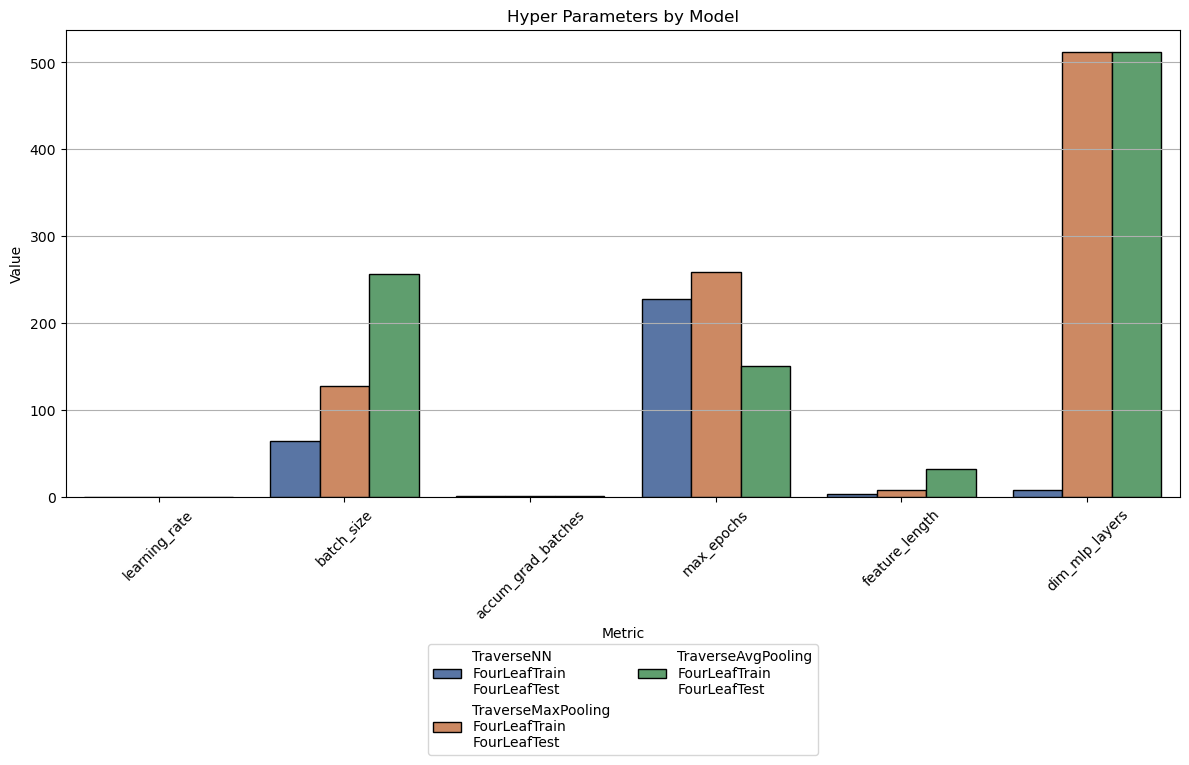

In [7]:
# barplot hyperparameters combined

df = melt_df.rename(columns={'label': 'Model'})

plt.figure(figsize=(2 * len(hyperparams),8))
plt.grid()
sns.barplot(x='Metric', y='Value', hue='Model', data=df, palette='deep')
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.title('Hyper Parameters by Model')
plt.show()

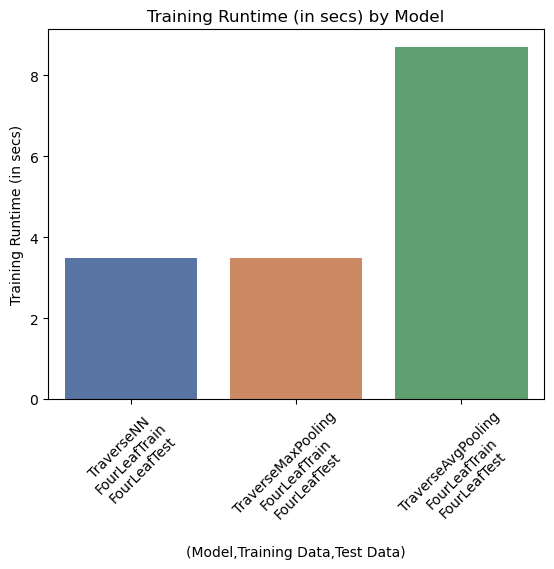

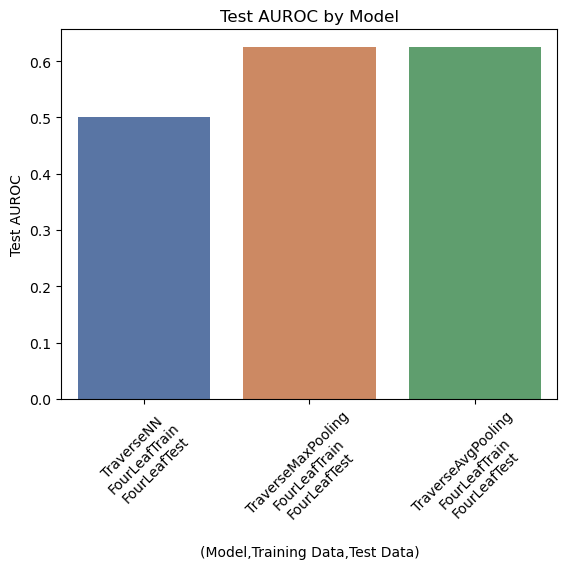

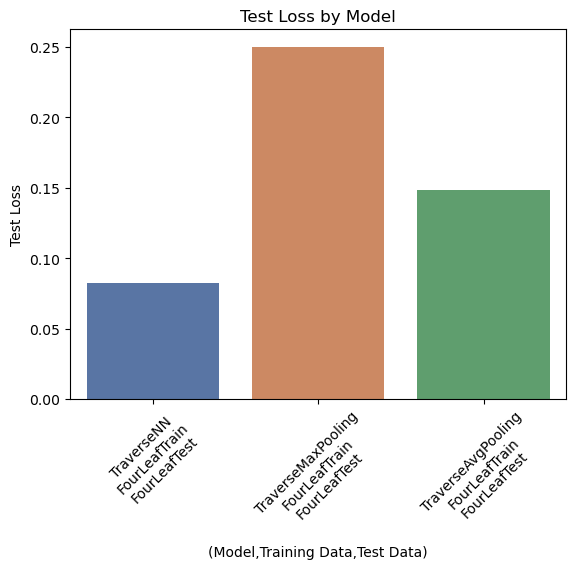

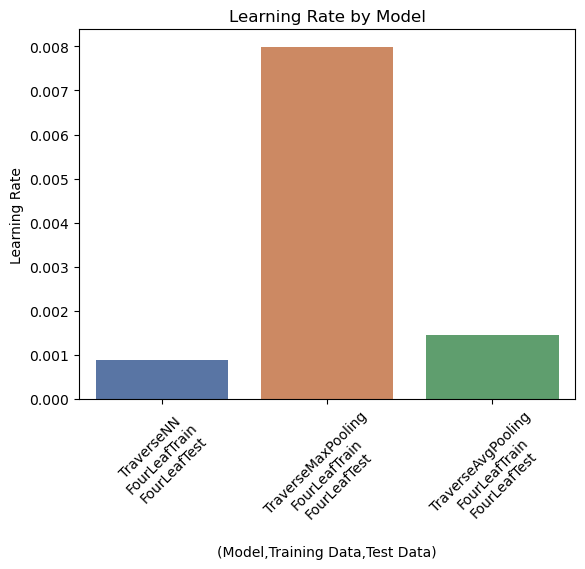

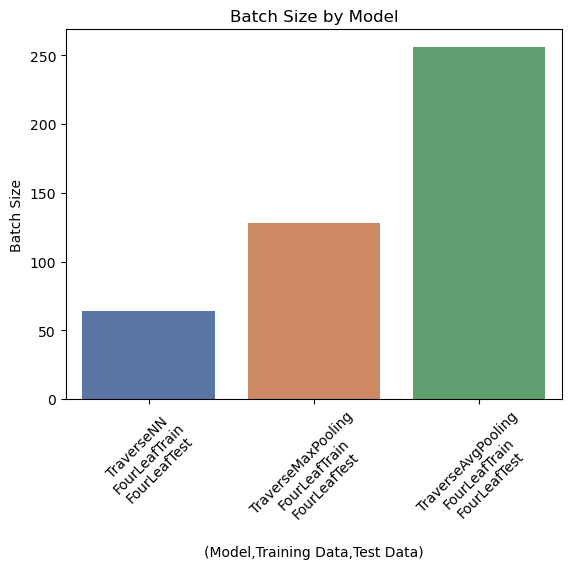

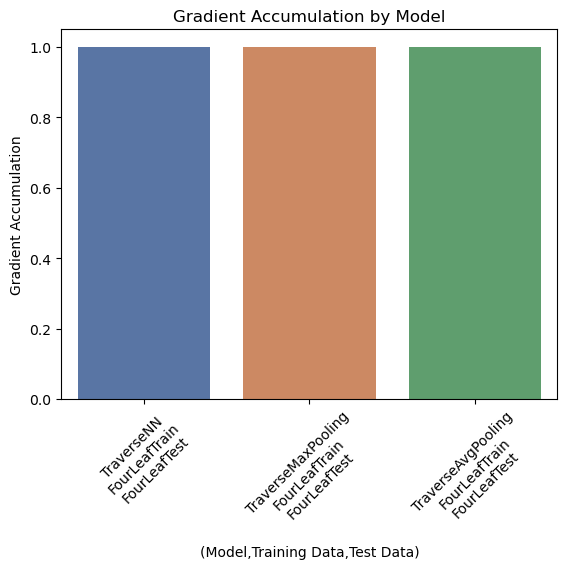

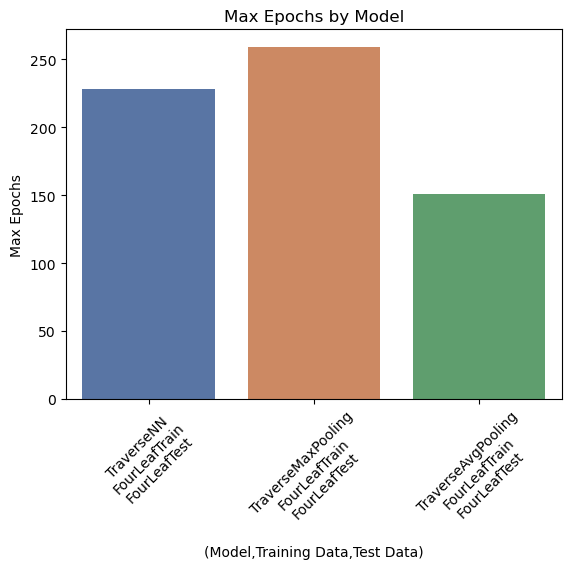

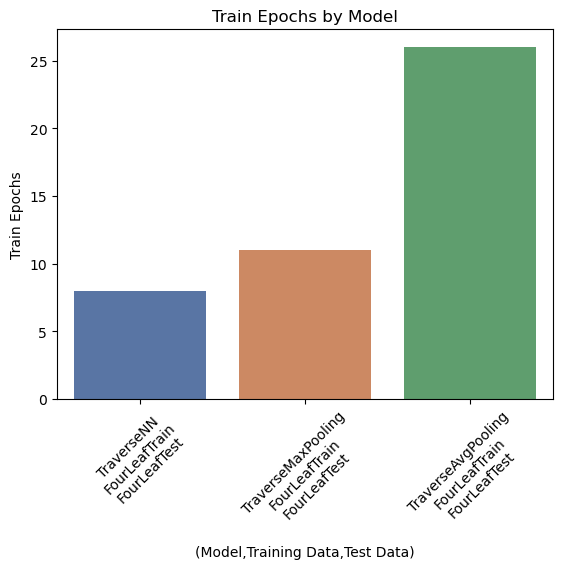

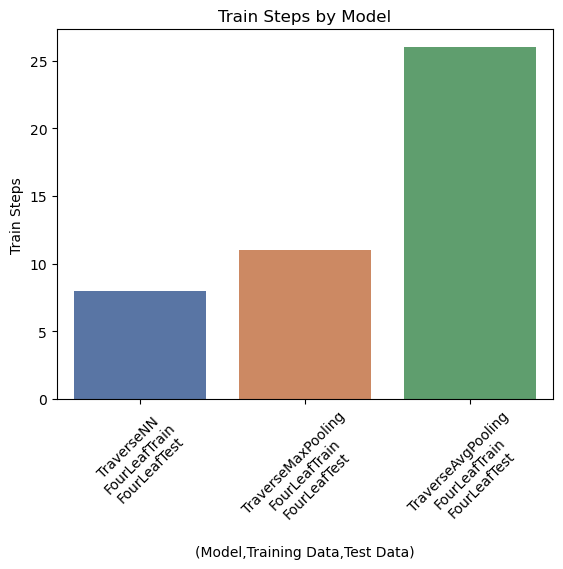

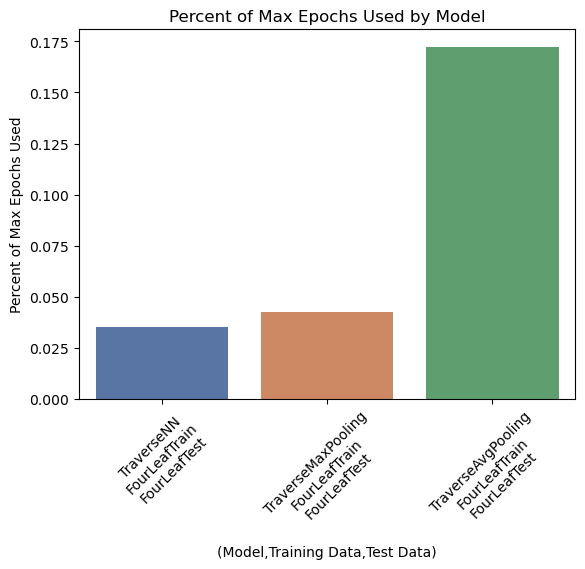

In [8]:
# individual bar plots

x_measures = {
  "Training Runtime (in secs)": "train_walltime",
  "Test AUROC": "test_auroc",
  "Test Loss": "test_loss",
  "Learning Rate": "learning_rate",
  "Batch Size": "batch_size",
  "Gradient Accumulation": "accum_grad_batches",
  "Max Epochs": "max_epochs",
  "Train Epochs": "train_epochs",
  "Train Steps": "train_steps",
  "Percent of Max Epochs Used": "percent_epochs",
}

for x_title,x_col in x_measures.items():
    sns.barplot(x="label", y=f"{x_col}", data=final_df, hue="label", palette='deep')
    plt.xlabel("(Model,Training Data,Test Data)")
    plt.ylabel(f"{x_title}")
    plt.title(f"{x_title} by Model")
    plt.xticks(rotation=45)
    plt.savefig(f'result_csvs_and_pdfs/{x_col}.barplot.pdf')
    plt.show()

In [9]:
for key,df in summary_dfs.items():
  print(set(df.tag))
  print(df[df.tag == 'loss_per_epoch'])

{'avgloss_per_epoch', 'walltime_per_epoch', 'walltime_per_batch', 'loss_per_batch'}
Empty DataFrame
Columns: [step, tag, value]
Index: []
{'avgloss_per_epoch', 'walltime_per_epoch', 'walltime_per_batch', 'loss_per_batch'}
Empty DataFrame
Columns: [step, tag, value]
Index: []
{'avgloss_per_epoch', 'walltime_per_epoch', 'walltime_per_batch', 'loss_per_batch'}
Empty DataFrame
Columns: [step, tag, value]
Index: []


/tmp/ipykernel_6466/1830824280.py:13: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df_tag.step, df_tag.value, label=key)


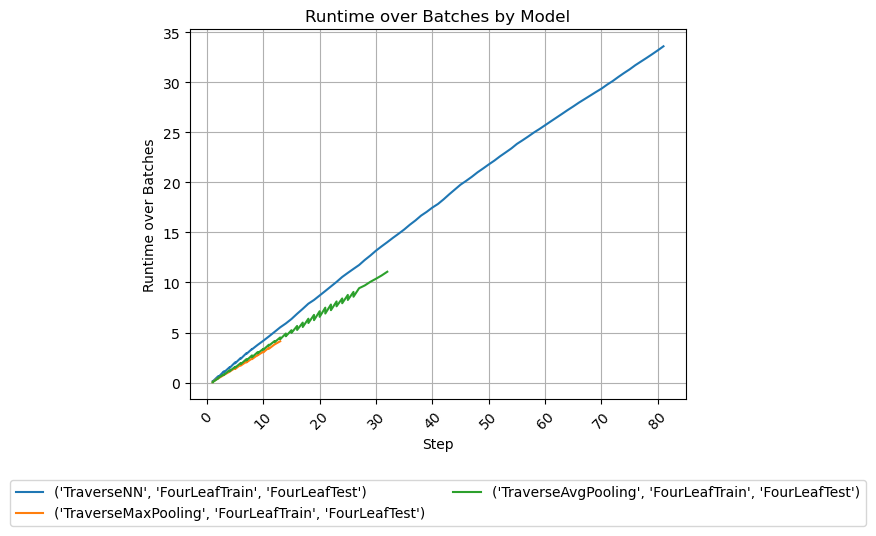

/tmp/ipykernel_6466/1830824280.py:13: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df_tag.step, df_tag.value, label=key)


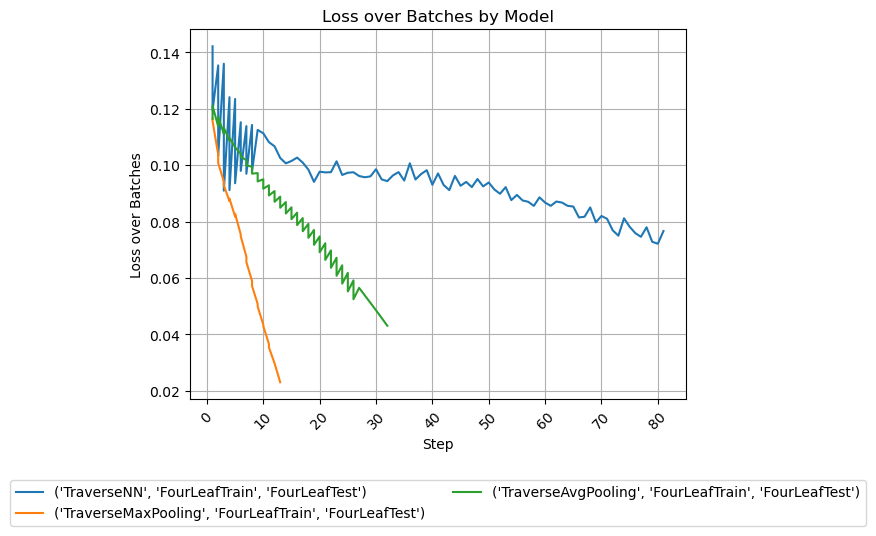

/tmp/ipykernel_6466/1830824280.py:13: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df_tag.step, df_tag.value, label=key)


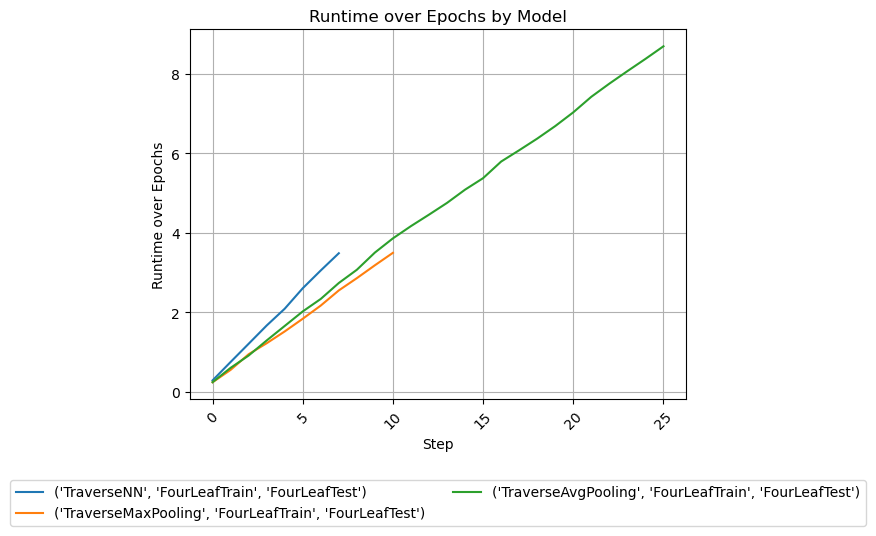

/tmp/ipykernel_6466/1830824280.py:13: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df_tag.step, df_tag.value, label=key)


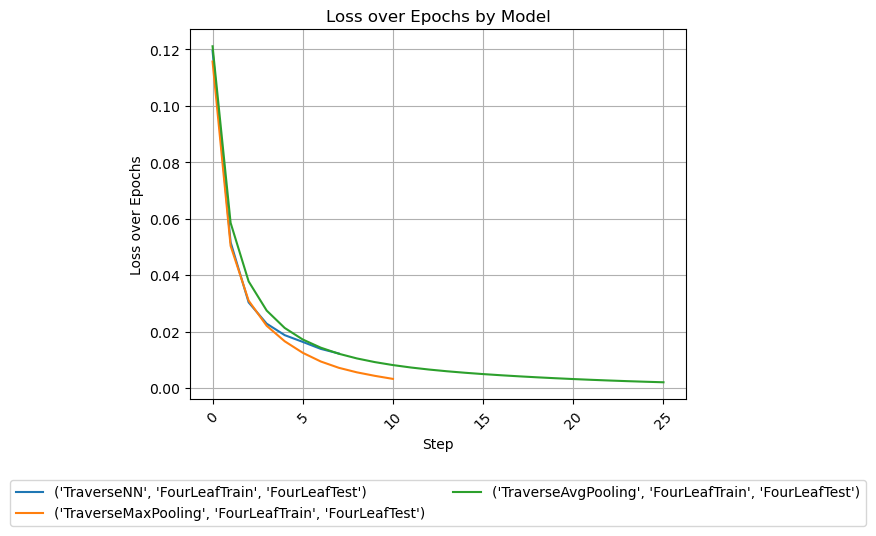

In [10]:
# line plots over epochs (using summary logs)

x_measures = {
  "Runtime over Batches": "walltime_per_batch",
  "Loss over Batches": "loss_per_batch",
  "Runtime over Epochs": "walltime_per_epoch",
  "Loss over Epochs": "avgloss_per_epoch",
}

for x_title,x_col in x_measures.items():
    for key,df in summary_dfs.items():
        df_tag = df[df.tag == x_col]
        plt.plot(df_tag.step, df_tag.value, label=key)

    plt.xlabel("Step")
    plt.ylabel(f"{x_title}")
    plt.title(f"{x_title} by Model")
    plt.xticks(rotation=45)

    plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
    plt.grid()
    plt.savefig(f'result_csvs_and_pdfs/{x_col}.lineplot.pdf')
    plt.show()

/tmp/ipykernel_6466/3882447044.py:6: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df_time.value, df_loss.value, label=key)


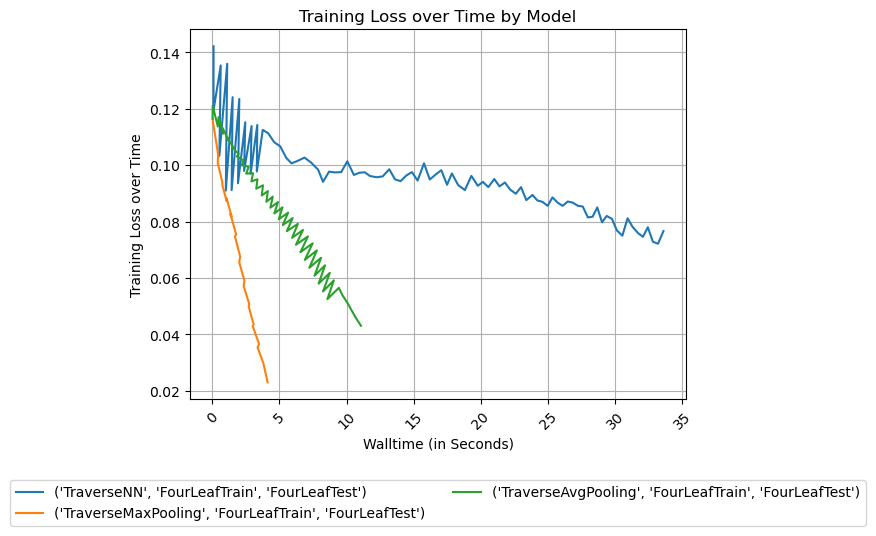

In [11]:
# line plot loss over walltime (using summary logs)

for key,df in summary_dfs.items():
    df_time = df[df.tag == 'walltime_per_batch']
    df_loss = df[df.tag == 'loss_per_batch']
    plt.plot(df_time.value, df_loss.value, label=key)

x_title = "Training Loss over Time"
plt.xlabel("Walltime (in Seconds)")
plt.ylabel(f"{x_title}")
plt.title(f"{x_title} by Model")
plt.xticks(rotation=45)

plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
plt.grid()
plt.savefig(f'result_csvs_and_pdfs/loss_per_walltime.lineplot.pdf')
plt.show()

/tmp/ipykernel_6466/1358472318.py:13: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df_tag.step, df_tag.value, label=key)


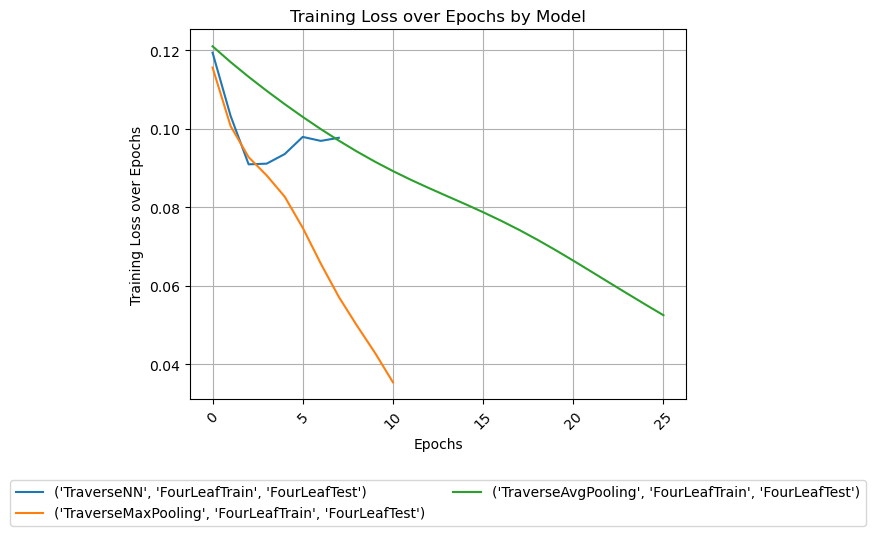

/tmp/ipykernel_6466/1358472318.py:13: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df_tag.step, df_tag.value, label=key)


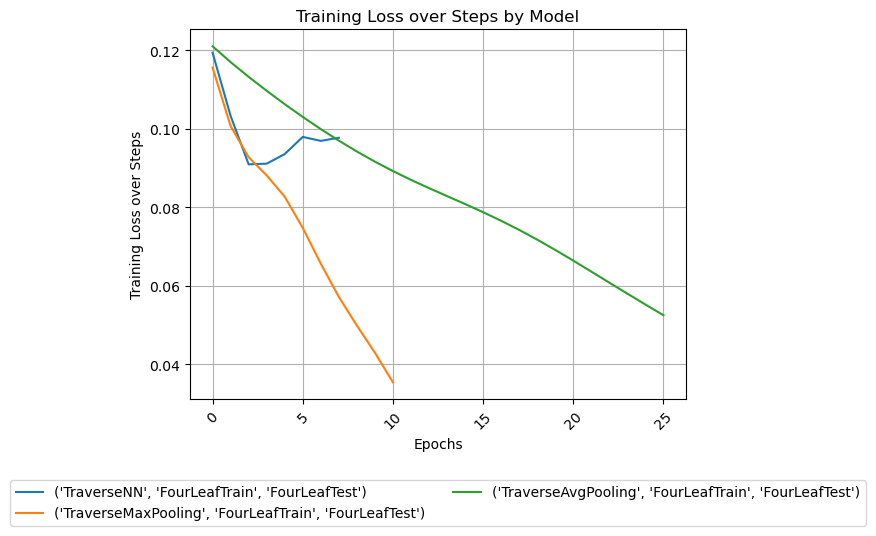

/tmp/ipykernel_6466/1358472318.py:13: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df_tag.step, df_tag.value, label=key)


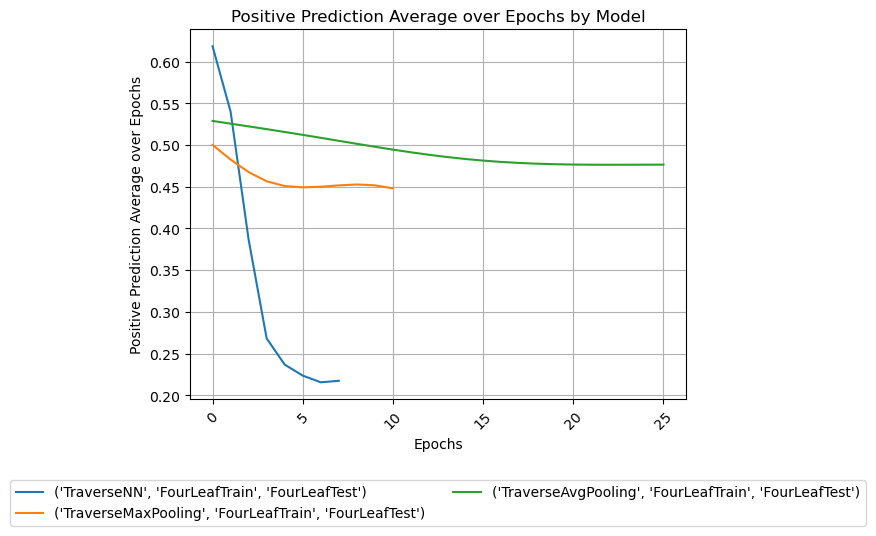

/tmp/ipykernel_6466/1358472318.py:13: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df_tag.step, df_tag.value, label=key)


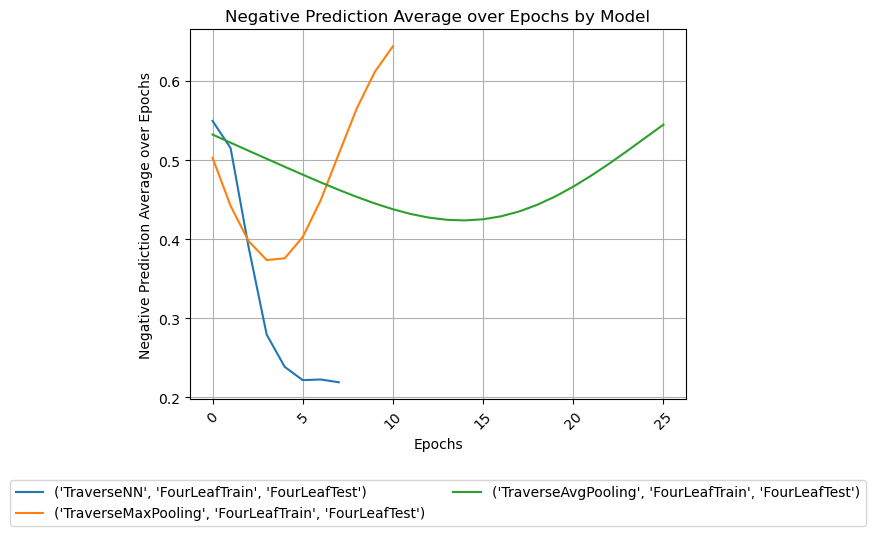

In [12]:
# line plots over epochs (using lightning logs)

x_measures = {
  "Training Loss over Epochs": "train_loss_epoch",
  "Training Loss over Steps": "train_loss_step",
  "Positive Prediction Average over Epochs": "pos_prediction_avg",
  "Negative Prediction Average over Epochs": "neg_prediction_avg",
}

for x_title,x_col in x_measures.items():
    for key,df in train_dfs.items():
        df_tag = df[df.tag == x_col]
        plt.plot(df_tag.step, df_tag.value, label=key)

    plt.xlabel("Epochs")
    plt.ylabel(f"{x_title}")
    plt.title(f"{x_title} by Model")
    plt.xticks(rotation=45)

    plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
    plt.grid()
    plt.savefig(f'result_csvs_and_pdfs/{x_col}.lineplot.pdf')
    plt.show()